# 04_Customer_Analytics

Business analytics and visualization notebook using `master_df.parquet`.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

PROCESSED_DATA = Path("../data/processed")
master_df = pd.read_parquet(PROCESSED_DATA / "master_df.parquet")
master_df = master_df.copy()


## Dataset Validation

In [12]:
print("Shape:", master_df.shape)
display(master_df.dtypes.to_frame("dtype").head(20))
display(master_df.isna().sum().sort_values(ascending=False).head(20))
print("Duplicate rows:", master_df.duplicated().sum())


Shape: (2530433, 49)


,dtype
order_id,object
customer_id,object
order_status,category
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
customer_unique_id,object
customer_name,object


order_delivered_customer_date    167729
order_delivered_carrier_date     167729
review_score                     167729
review_comment_title             167729
review_comment_message           167729
review_id                        167729
review_creation_date             167729
review_answer_timestamp          167729
order_id                              0
customer_name                         0
customer_gender                       0
customer_id                           0
order_status                          0
order_approved_at                     0
order_purchase_timestamp              0
order_estimated_delivery_date         0
customer_unique_id                    0
order_item_id                         0
customer_segment                      0
customer_state                        0
dtype: int64

Duplicate rows: 0


## KPI Dashboard

In [3]:
revenue_col = "price_x" if "price_x" in master_df.columns else "price"
order_col = "order_id"
cust_col = "customer_unique_id" if "customer_unique_id" in master_df.columns else "customer_id"

total_revenue = master_df[revenue_col].sum()
total_orders = master_df[order_col].nunique()
total_customers = master_df[cust_col].nunique()
aov = total_revenue / max(total_orders,1)
rpc = total_revenue / max(total_customers,1)

print({
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Average Order Value": aov,
    "Revenue Per Customer": rpc
})


{'Total Revenue': np.float32(1.1313012e+09), 'Total Orders': 1000000, 'Total Customers': 279199, 'Average Order Value': np.float32(1131.3013), 'Revenue Per Customer': np.float32(4051.9531)}


## RFM Analysis

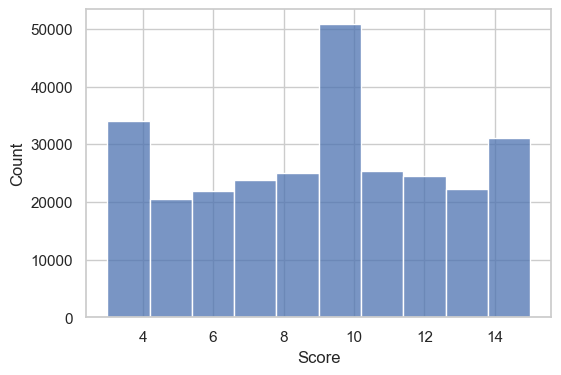

In [4]:
df=master_df.copy()
date_col="order_purchase_timestamp"
df[date_col]=pd.to_datetime(df[date_col])
snapshot=df[date_col].max()+pd.Timedelta(days=1)
rfm=df.groupby(cust_col).agg(
Recency=(date_col,lambda x:(snapshot-x.max()).days),
Frequency=(order_col,"nunique"),
Monetary=(revenue_col,"sum"))
rfm["R"]=pd.qcut(rfm["Recency"].rank(method="first"),5,labels=[5,4,3,2,1])
rfm["F"]=pd.qcut(rfm["Frequency"].rank(method="first"),5,labels=[1,2,3,4,5])
rfm["M"]=pd.qcut(rfm["Monetary"].rank(method="first"),5,labels=[1,2,3,4,5])
rfm["Score"]=rfm[["R","F","M"]].astype(int).sum(axis=1)
plt.figure(figsize=(6,4))
sns.histplot(rfm["Score"],bins=10)
plt.show()


## Cohort Analysis

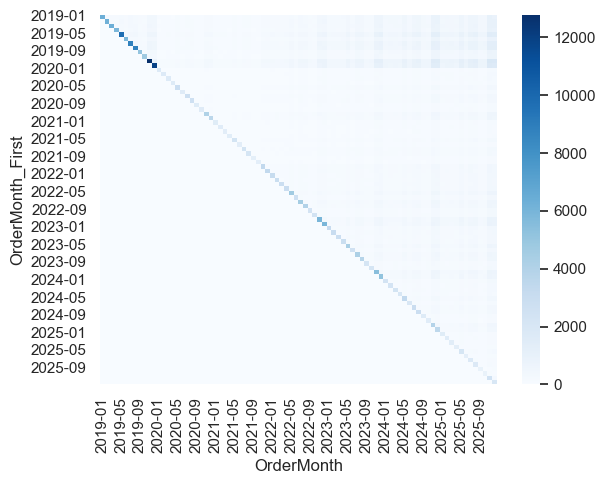

In [5]:
df=master_df.copy()
df["OrderMonth"]=pd.to_datetime(df[date_col]).dt.to_period("M")
first=df.groupby(cust_col)["OrderMonth"].min()
df=df.join(first,on=cust_col,rsuffix="_First")
cohort=(df.groupby(["OrderMonth_First","OrderMonth"])[cust_col]
.nunique().unstack(fill_value=0))
sns.heatmap(cohort,cmap="Blues")
plt.show()


## Customer Segmentation

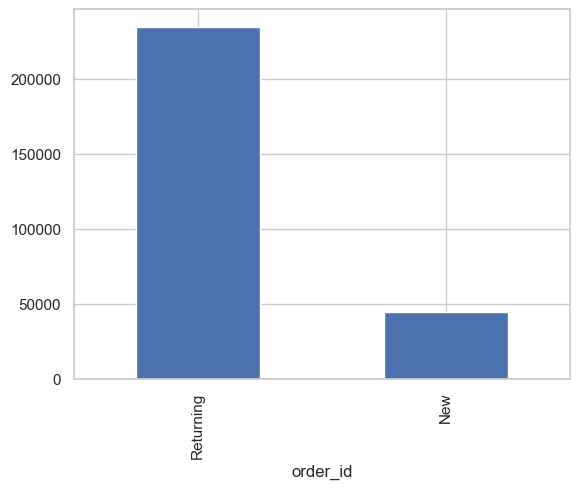

In [6]:
counts=master_df.groupby(cust_col)[order_col].nunique()
seg=counts.map(lambda x:"Returning" if x>1 else "New")
seg.value_counts().plot(kind="bar")
plt.show()


## ABC Analysis

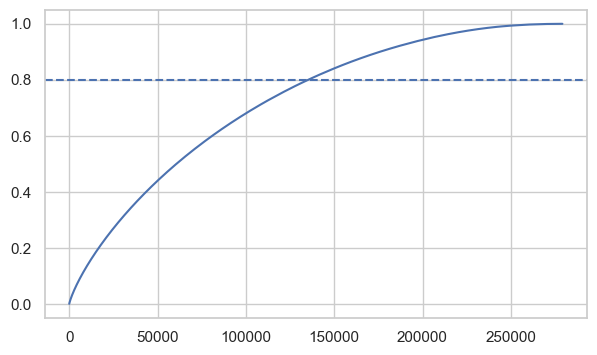

In [7]:
sales=master_df.groupby(cust_col)[revenue_col].sum().sort_values(ascending=False)
cum=sales.cumsum()/sales.sum()
plt.figure(figsize=(7,4))
plt.plot(cum.values)
plt.axhline(.8,ls="--")
plt.show()


## Customer Journey

In [8]:
timeline=master_df.copy()
for c in ["order_purchase_timestamp","order_approved_at","order_delivered_customer_date"]:
    if c in timeline.columns:
        timeline[c]=pd.to_datetime(timeline[c])
print("Journey timeline prepared.")


Journey timeline prepared.


## Executive Dashboard

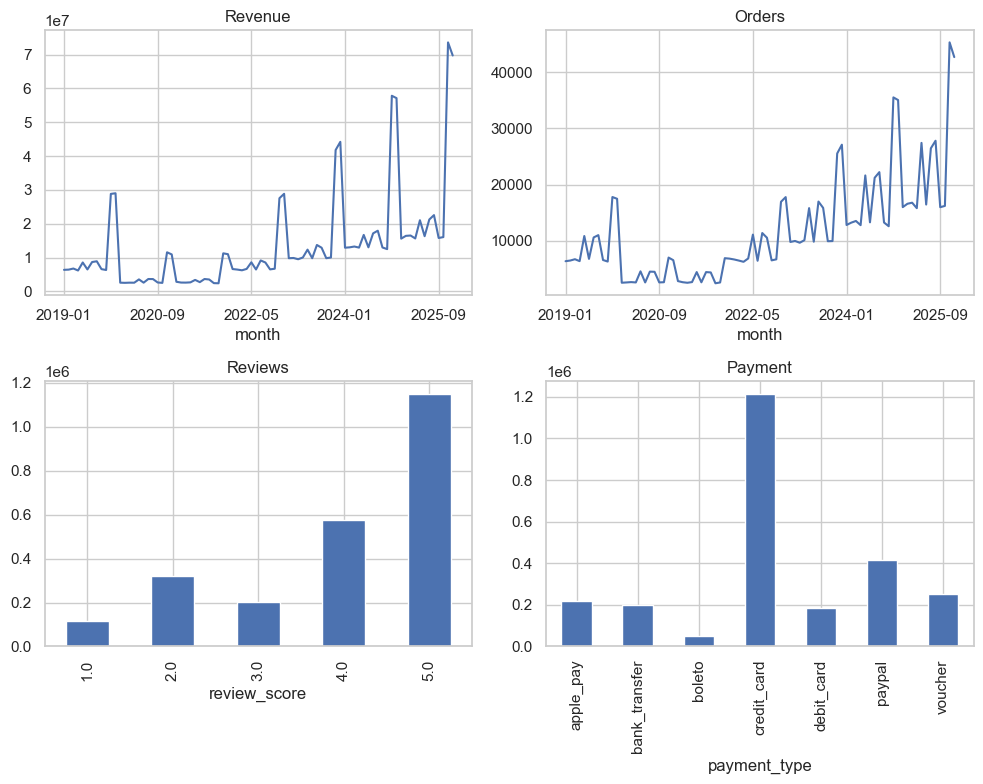

In [9]:
fig,ax=plt.subplots(2,2,figsize=(10,8))
monthly=master_df.assign(month=pd.to_datetime(master_df[date_col]).dt.to_period("M").astype(str))
monthly.groupby("month")[revenue_col].sum().plot(ax=ax[0,0],title="Revenue")
monthly.groupby("month")[order_col].nunique().plot(ax=ax[0,1],title="Orders")
master_df.groupby("review_score").size().plot(kind="bar",ax=ax[1,0],title="Reviews") if "review_score" in master_df.columns else None
master_df.groupby("payment_type").size().plot(kind="bar",ax=ax[1,1],title="Payment") if "payment_type" in master_df.columns else None
plt.tight_layout()
plt.show()


## Final Summary

In [10]:
print("Customer analytics completed successfully.")

Customer analytics completed successfully.
